# Study 2 - Model Development and Fine-Tuning
### Explainable Deep Learning for Diabetic Retinopathy Severity Grading
### MAI204 - Computer Vision - Milestone 3

**Owner:** Peter Bello
**Group 5:** Alain Dika (131613259), Peter Bello (138475256), Ritika Lal (130865256)


## 0. Study overview

**Research question.** Which deep-learning architecture and fine-tuning strategy provides the best
validation QWK, generalization, and computational efficiency for five-class diabetic retinopathy
grading on APTOS 2019?

**Design.** Two controlled stages, run under the shared project protocol:

1. **Stage 1 - architecture comparison.** Train three architectures (custom CNN, ImageNet
   ResNet-50, ImageNet EfficientNet-B0) under the same protocol. Select the strongest by
   validation QWK, breaking ties by macro-F1, then validation loss.
2. **Stage 2 - fine-tuning strategy.** On the Stage 1 winner (constrained to a pretrained
   architecture), compare three fine-tuning depths: frozen backbone, partial fine-tuning
   (classifier + last backbone stage), full fine-tuning.

**Fixed controls (shared project protocol).** APTOS 2019, stratified 70/15/15 split with seed 42,
224x224 RGB with the shared baseline preprocessing pipeline (retinal-field crop -> resize ->
ImageNet normalization), Adam (lr=1e-3, weight_decay=1e-4), ReduceLROnPlateau (patience=2,
factor=0.1), max 30 epochs, early stopping patience=5 on validation QWK, batch size 32,
unweighted cross-entropy loss.

**Out of scope (owned by other members).** CLAHE / gamma / histogram-equalization preprocessing
(Ritika, Study 1). Weighted losses, weighted samplers, class-targeted augmentation, and Grad-CAM
/ IG / Occlusion XAI comparisons (Alain, Study 3).

In [143]:
import shutil
shutil.make_archive("/kaggle/working/study2_outputs", "zip", "/kaggle/working", "artifacts")
shutil.make_archive("/kaggle/working/study2_configs", "zip", "/kaggle/working", "configs")
print("Zipped")

Zipped


In [144]:
import os
for root, dirs, files in os.walk("/kaggle/working/artifacts"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/working/artifacts/checkpoints/stage1_custom_cnn.pth
/kaggle/working/artifacts/checkpoints/stage2_efficientnet_b0_full.pth
/kaggle/working/artifacts/checkpoints/stage2_efficientnet_b0_partial.pth
/kaggle/working/artifacts/checkpoints/stage1_resnet50.pth
/kaggle/working/artifacts/checkpoints/stage1_efficientnet_b0.pth
/kaggle/working/artifacts/checkpoints/stage2_efficientnet_b0_frozen.pth
/kaggle/working/artifacts/graphs/final_training_curves.png
/kaggle/working/artifacts/graphs/final_confusion_matrix.png
/kaggle/working/artifacts/results/finetuning_comparison.csv
/kaggle/working/artifacts/results/architecture_comparison.csv
/kaggle/working/artifacts/training_curves/stage1_val_curves.png
/kaggle/working/artifacts/training_curves/stage2_val_curves.png


In [145]:
import os

# Check working directory
print("Working directory contents:")
for f in os.listdir("/kaggle/working"):
    print(f)

Working directory contents:
artifacts
study2_configs.zip
study2_outputs.zip
.virtual_documents
__pycache__
data
training_utils.py
aptos_seed42.csv
configs
models.py


In [146]:
from IPython.display import FileLink
FileLink('study2_outputs.zip')

/kaggle/working/study2_outputs.zip

In [147]:
from IPython.display import FileLink
FileLink('study2_configs.zip')

/kaggle/working/study2_configs.zip

In [115]:
import os

print("model-1/other/default:")
print(os.listdir("/kaggle/input/models/petrbello/model-1/other/default"))

print("\ntraining-util/other/default:")
print(os.listdir("/kaggle/input/models/petrbello/training-util/other/default"))

model-1/other/default:
['1']

training-util/other/default:
['1']


In [116]:
import os

print("model-1/other/default/1:")
print(os.listdir("/kaggle/input/models/petrbello/model-1/other/default/1"))

print("\ntraining-util/other/default/1:")
print(os.listdir("/kaggle/input/models/petrbello/training-util/other/default/1"))

model-1/other/default/1:
['models.py']

training-util/other/default/1:
['training_utils.py']


In [117]:
import shutil
from pathlib import Path

# Copy files to working directory
shutil.copy("/kaggle/input/models/petrbello/model-1/other/default/1/models.py", "/kaggle/working/models.py")
shutil.copy("/kaggle/input/models/petrbello/training-util/other/default/1/training_utils.py", "/kaggle/working/training_utils.py")
shutil.copy("/kaggle/input/datasets/petrbello/aptos-seed42-csv/aptos_seed42.csv", "/kaggle/working/aptos_seed42.csv")

print("Files copied:")
print(os.listdir("/kaggle/working"))

Files copied:
['artifacts', '.virtual_documents', '__pycache__', 'data', 'training_utils.py', 'aptos_seed42.csv', 'models.py']


In [118]:
!pip install -q pyyaml

In [119]:
with open("/kaggle/working/training_utils.py", "r") as f:
    src = f.read()
old = '''    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = self.image_root / row["image_path"]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        label = int(row["diagnosis"])
        return img, label'''
new = '''    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = self.image_root / (str(row["id_code"]) + ".png")
        from PIL import Image
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        label = int(row["diagnosis"])
        return img, label'''
src = src.replace(old, new)
with open("/kaggle/working/training_utils.py", "w") as f:
    f.write(src)
print("training_utils.py patched")

training_utils.py patched


In [120]:
from pathlib import Path
Path("/kaggle/working/data/splits").mkdir(parents=True, exist_ok=True)
import shutil
shutil.copy("/kaggle/working/aptos_seed42.csv", "/kaggle/working/data/splits/aptos_seed42.csv")
print("CSV ready")

CSV ready


In [121]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [122]:
import os
print(os.listdir("/kaggle/input/datasets/mariaherrerot/aptos2019"))

['val_images', 'train_images', 'valid.csv', 'test.csv', 'train_1.csv', 'test_images']


In [123]:
import os
files = os.listdir("/kaggle/input/datasets/mariaherrerot/aptos2019/train_images")
print("Total:", len(files))
print("First 3:", files[:3])

Total: 1
First 3: ['train_images']


In [124]:
import os
files = os.listdir("/kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images")
print("Total:", len(files))
print("First 3:", files[:3])

Total: 2930
First 3: ['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png']


In [125]:
!unzip -q /content/data/aptos2019/aptos2019-blindness-detection.zip -d /content/data/aptos2019/
!ls /content/data/aptos2019/train_images/ | wc -l

unzip:  cannot find or open /content/data/aptos2019/aptos2019-blindness-detection.zip, /content/data/aptos2019/aptos2019-blindness-detection.zip.zip or /content/data/aptos2019/aptos2019-blindness-detection.zip.ZIP.
ls: cannot access '/content/data/aptos2019/train_images/': No such file or directory
0


In [126]:
!mkdir -p "/content/drive/MyDrive/aptos2019"
!cp -r /content/data/aptos2019/train_images "/content/drive/MyDrive/aptos2019/"
!cp /content/aptos_seed42.csv "/content/drive/MyDrive/"
print("Saved to Drive permanently")

cp: cannot stat '/content/data/aptos2019/train_images': No such file or directory
cp: cannot stat '/content/aptos_seed42.csv': No such file or directory
Saved to Drive permanently


In [127]:
from pathlib import Path
Path("/content/data/splits").mkdir(parents=True, exist_ok=True)
!cp "/content/drive/MyDrive/aptos_seed42.csv" /content/data/splits/aptos_seed42.csv
!pip install -q pyyaml
print("Ready")

cp: cannot stat '/content/drive/MyDrive/aptos_seed42.csv': No such file or directory
Ready


In [128]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


## 1. Setup and configuration

In [129]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from torch.utils.data import DataLoader
from torchvision import transforms

# Local reusable modules (kept alongside this notebook)
from models import build_model, VALID_ARCHS, VALID_FREEZE
from training_utils import (APTOSDataset, TrainConfig, compute_metrics, load_split,
                            measure_inference_time, train_model)

# --- shared project paths ---
ROOT = Path("/kaggle/working")
SPLIT_CSV = ROOT / "data" / "splits" / "aptos_seed42.csv"
IMAGE_ROOT = Path("/kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images")
CKPT_DIR = ROOT / "artifacts" / "checkpoints"
RESULTS_DIR = ROOT / "artifacts" / "results"
CURVES_DIR = ROOT / "artifacts" / "training_curves"
GRAPHS_DIR = ROOT / "artifacts" / "graphs"
for d in (CKPT_DIR, RESULTS_DIR, CURVES_DIR, GRAPHS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- shared hyperparameters (Recommended_Training_Configuration.pdf) ---
NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED); np.random.seed(SEED)
print(f"Device: {DEVICE}")
print(f"Split: {SPLIT_CSV}")
print(f"Images: {IMAGE_ROOT}")


Device: cuda
Split: /kaggle/working/data/splits/aptos_seed42.csv
Images: /kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images


## 2. Shared baseline preprocessing and dataloaders

This is the *shared standard pipeline* fixed by the project contract: retinal-field crop (the
CircleCropTransform below removes the black borders present in APTOS fundus photos), resize to
224x224, tensor conversion, and ImageNet normalization. This pipeline is identical to Ritika's
Pipeline A ("Baseline") in Study 1 so the two studies remain directly comparable.

In [130]:
class CircleCropTransform:
    """
    Crop the retinal field from a fundus image by finding the bounding box of the
    largest bright region and cropping to it. Matches the "retinal-field crop"
    step in the shared baseline preprocessing pipeline.
    """
    def __init__(self, tol: int = 7):
        self.tol = tol

    def __call__(self, img):
        arr = np.array(img)
        gray = arr.mean(axis=2) if arr.ndim == 3 else arr
        mask = gray > self.tol
        if mask.sum() == 0:
            return img
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        cropped = arr[y0:y1 + 1, x0:x1 + 1]
        from PIL import Image
        return Image.fromarray(cropped)


shared_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_df, val_df, test_df = load_split(SPLIT_CSV)
train_ds = APTOSDataset(train_df, IMAGE_ROOT, shared_transform)
val_ds   = APTOSDataset(val_df,   IMAGE_ROOT, shared_transform)
test_ds  = APTOSDataset(test_df,  IMAGE_ROOT, shared_transform)

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")
print("Class distribution (train):")
print(train_df["diagnosis"].value_counts().sort_index())


train=2563  val=549  test=550
Class distribution (train):
diagnosis
0    1263
1     259
2     699
3     135
4     207
Name: count, dtype: int64


## 3. Stage 1 - Architecture comparison

Three architectures under an identical protocol:
- **custom_cnn** - a from-scratch reference (no ImageNet weights). Establishes what the model can
  learn without transfer learning.
- **resnet50** - the shared baseline pretrained architecture (ImageNet-V2 weights, 5-class head).
- **efficientnet_b0** - a parameter-efficient pretrained alternative (ImageNet-V1 weights,
  5-class head).

Each is trained under Stage 1 as **full fine-tuning** (pretrained models start from ImageNet
weights but all layers are trainable) so the comparison isolates architecture, not adaptation
depth. Adaptation depth is the Stage 2 variable.

In [131]:
# Filter to only images that exist in this dataset version
import os
available = set(f.replace(".png", "") for f in 
                os.listdir("/kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images"))
print(f"Available images: {len(available)}")

train_df = train_df[train_df["id_code"].isin(available)].reset_index(drop=True)
val_df   = val_df[val_df["id_code"].isin(available)].reset_index(drop=True)
test_df  = test_df[test_df["id_code"].isin(available)].reset_index(drop=True)

print(f"Filtered split: train={len(train_df)} val={len(val_df)} test={len(test_df)}")

Available images: 2930
Filtered split: train=2051 val=448 test=431


In [132]:
train_ds = APTOSDataset(train_df, IMAGE_ROOT, shared_transform)
val_ds   = APTOSDataset(val_df,   IMAGE_ROOT, shared_transform)
test_ds  = APTOSDataset(test_df,  IMAGE_ROOT, shared_transform)

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

train=2051  val=448  test=431


In [133]:
stage1_cfg = TrainConfig(max_epochs=30, patience=5, lr=1e-3, weight_decay=1e-4,
                        scheduler_patience=2, scheduler_factor=0.1)

stage1_results = {}   # arch -> {model_info, train_result, inference_ms}
for arch in VALID_ARCHS:
    print(f"\n=== Stage 1: training {arch} ===")
    info = build_model(arch=arch, num_classes=NUM_CLASSES, pretrained=True, freeze_mode="full")
    print(f"  total_params={info.total_params:,}  trainable_params={info.trainable_params:,}")
    ckpt = CKPT_DIR / f"stage1_{arch}.pth"
    tr = train_model(info.model, train_loader, val_loader, stage1_cfg,
                     DEVICE, ckpt, experiment_id=f"S1/{arch}")
    ms = measure_inference_time(info.model, DEVICE, IMAGE_SIZE)
    stage1_results[arch] = {"info": info, "result": tr, "inference_ms": ms}
    print(f"  best epoch={tr.best_epoch}  val_qwk={tr.best_val_qwk:.4f}  "
          f"train_time={tr.train_time_sec:.1f}s  infer={ms:.2f} ms/img")



=== Stage 1: training custom_cnn ===
  total_params=1,206,757  trainable_params=1,206,757
[S1/custom_cnn] epoch 01  tr_loss=1.051 vl_loss=0.887  tr_qwk=0.433 vl_qwk=0.593  vl_f1=0.307 vl_acc=0.701
[S1/custom_cnn] epoch 02  tr_loss=0.867 vl_loss=0.869  tr_qwk=0.646 vl_qwk=0.643  vl_f1=0.308 vl_acc=0.701
[S1/custom_cnn] epoch 03  tr_loss=0.836 vl_loss=0.871  tr_qwk=0.662 vl_qwk=0.653  vl_f1=0.307 vl_acc=0.699
[S1/custom_cnn] epoch 04  tr_loss=0.809 vl_loss=0.856  tr_qwk=0.662 vl_qwk=0.632  vl_f1=0.311 vl_acc=0.705
[S1/custom_cnn] epoch 05  tr_loss=0.808 vl_loss=0.903  tr_qwk=0.662 vl_qwk=0.605  vl_f1=0.313 vl_acc=0.692
[S1/custom_cnn] epoch 06  tr_loss=0.799 vl_loss=0.899  tr_qwk=0.659 vl_qwk=0.542  vl_f1=0.340 vl_acc=0.692
[S1/custom_cnn] epoch 07  tr_loss=0.771 vl_loss=1.225  tr_qwk=0.692 vl_qwk=0.450  vl_f1=0.256 vl_acc=0.542
[S1/custom_cnn] epoch 08  tr_loss=0.764 vl_loss=0.775  tr_qwk=0.675 vl_qwk=0.677  vl_f1=0.342 vl_acc=0.705
[S1/custom_cnn] epoch 09  tr_loss=0.733 vl_loss=0.770

100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


  total_params=23,518,277  trainable_params=23,518,277


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784300d4f6a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x784300d4f6a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[S1/resnet50] epoch 01  tr_loss=0.764 vl_loss=0.673  tr_qwk=0.652 vl_qwk=0.749  vl_f1=0.458 vl_acc=0.768
[S1/resnet50] epoch 02  tr_loss=0.441 vl_loss=0.606  tr_qwk=0.879 vl_qwk=0.819  vl_f1=0.503 vl_acc=0.786
[S1/resnet50] epoch 03  tr_loss=0.222 vl_loss=0.744  tr_qwk=0.947 vl_qwk=0.764  vl_f1=0.547 vl_acc=0.781
[S1/resnet50] epoch 04  tr_loss=0.088 vl_loss=0.817  tr_qwk=0.986 vl_qwk=0.831  vl_f1=0.612 vl_acc=0.801
[S1/resnet50] epoch 05  tr_loss=0.054 vl_loss=0.952  tr_qwk=0.992 vl_qwk=0.821  vl_f1=0.581 vl_acc=0.801
[S1/resnet50] epoch 06  tr_loss=0.033 vl_loss=0.828  tr_qwk=0.995 vl_qwk=0.814  vl_f1=0.613 vl_acc=0.799
[S1/resnet50] epoch 07  tr_loss=0.025 vl_loss=0.890  tr_qwk=0.995 vl_qwk=0.829  vl_f1=0.610 vl_acc=0.810
[S1/resnet50] epoch 08  tr_loss=0.022 vl_loss=0.884  tr_qwk=0.996 vl_qwk=0.817  vl_f1=0.593 vl_acc=0.795
[S1/resnet50] epoch 09  tr_loss=0.018 vl_loss=0.877  tr_qwk=0.997 vl_qwk=0.816  vl_f1=0.583 vl_acc=0.788
[S1/resnet50] early stop at epoch 9, no val_qwk improve

100%|██████████| 20.5M/20.5M [00:00<00:00, 148MB/s]


  total_params=4,013,953  trainable_params=4,013,953
[S1/efficientnet_b0] epoch 01  tr_loss=0.797 vl_loss=0.648  tr_qwk=0.708 vl_qwk=0.770  vl_f1=0.508 vl_acc=0.759
[S1/efficientnet_b0] epoch 02  tr_loss=0.488 vl_loss=0.576  tr_qwk=0.859 vl_qwk=0.824  vl_f1=0.602 vl_acc=0.804
[S1/efficientnet_b0] epoch 03  tr_loss=0.345 vl_loss=0.646  tr_qwk=0.911 vl_qwk=0.825  vl_f1=0.615 vl_acc=0.795
[S1/efficientnet_b0] epoch 04  tr_loss=0.242 vl_loss=0.640  tr_qwk=0.949 vl_qwk=0.841  vl_f1=0.636 vl_acc=0.792
[S1/efficientnet_b0] epoch 05  tr_loss=0.177 vl_loss=0.690  tr_qwk=0.964 vl_qwk=0.829  vl_f1=0.666 vl_acc=0.806
[S1/efficientnet_b0] epoch 06  tr_loss=0.124 vl_loss=0.645  tr_qwk=0.978 vl_qwk=0.830  vl_f1=0.676 vl_acc=0.817
[S1/efficientnet_b0] epoch 07  tr_loss=0.102 vl_loss=0.690  tr_qwk=0.984 vl_qwk=0.837  vl_f1=0.682 vl_acc=0.815
[S1/efficientnet_b0] epoch 08  tr_loss=0.109 vl_loss=0.688  tr_qwk=0.985 vl_qwk=0.835  vl_f1=0.673 vl_acc=0.812
[S1/efficientnet_b0] epoch 09  tr_loss=0.098 vl_los

### Stage 1 comparison table and CSV

In [134]:
def stage_rows(results, stage_label):
    rows = []
    for name, r in results.items():
        info = r["info"]; tr = r["result"]; m = tr.best_val_metrics
        rows.append({
            "stage": stage_label,
            "experiment": name,
            "total_params": info.total_params,
            "trainable_params": info.trainable_params,
            "best_epoch": tr.best_epoch,
            "train_time_sec": round(tr.train_time_sec, 1),
            "inference_ms_per_image": round(r["inference_ms"], 2),
            "val_qwk": round(tr.best_val_qwk, 4),
            "val_macro_f1": round(m.get("macro_f1", 0.0), 4),
            "val_accuracy": round(m.get("accuracy", 0.0), 4),
            "val_balanced_accuracy": round(m.get("balanced_accuracy", 0.0), 4),
            "val_macro_recall": round(m.get("macro_recall", 0.0), 4),
            "stopped_early": tr.stopped_early,
            "checkpoint": tr.checkpoint_path,
        })
    return rows


stage1_rows = stage_rows(stage1_results, "S1_architecture")
stage1_df = pd.DataFrame(stage1_rows)
stage1_df.to_csv(RESULTS_DIR / "architecture_comparison.csv", index=False)
stage1_df


,stage,experiment,total_params,trainable_params,best_epoch,train_time_sec,inference_ms_per_image,val_qwk,val_macro_f1,val_accuracy,val_balanced_accuracy,val_macro_recall,stopped_early,checkpoint
0,S1_architecture,custom_cnn,1206757,1206757,16,3338.4,2.54,0.7215,0.3634,0.7165,0.3919,0.3919,True,/kaggle/working/artifacts/checkpoints/stage1_c...
1,S1_architecture,resnet50,23518277,23518277,4,1406.4,5.57,0.8310,0.6119,0.8013,0.5889,0.5889,True,/kaggle/working/artifacts/checkpoints/stage1_r...
2,S1_architecture,efficientnet_b0,4013953,4013953,4,1439.9,8.93,0.8414,0.6362,0.7924,0.6313,0.6313,True,/kaggle/working/artifacts/checkpoints/stage1_e...


### Stage 1 training curves and selection

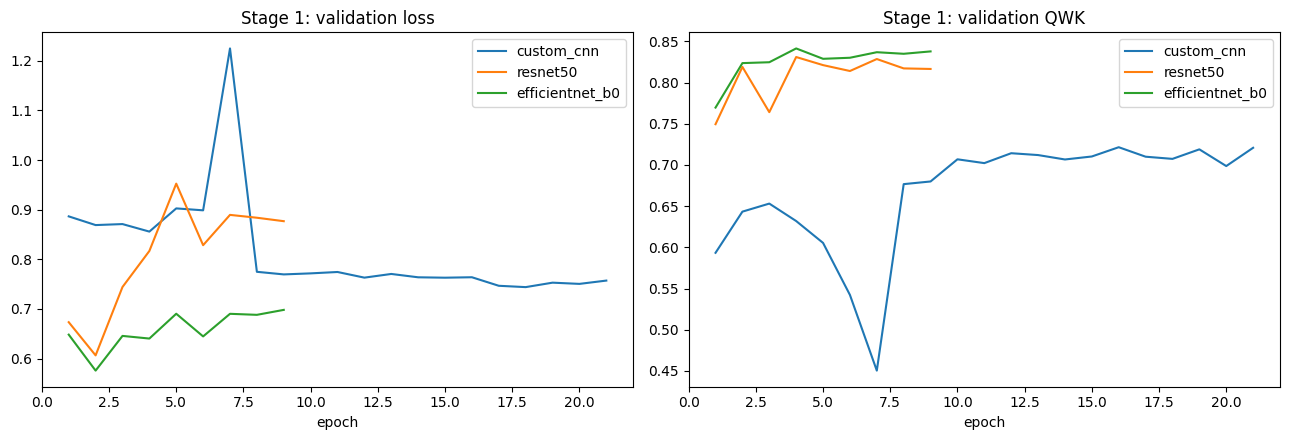

Stage 1 winner (by val QWK / macro F1): efficientnet_b0


In [135]:
def plot_curves(results, stage_label, path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for name, r in results.items():
        h = pd.DataFrame(r["result"].history)
        axes[0].plot(h["epoch"], h["val_loss"], label=name)
        axes[1].plot(h["epoch"], h["val_qwk"],  label=name)
    axes[0].set_title(f"{stage_label}: validation loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].set_title(f"{stage_label}: validation QWK");  axes[1].set_xlabel("epoch"); axes[1].legend()
    fig.tight_layout(); fig.savefig(path, dpi=150, bbox_inches="tight"); plt.show()


plot_curves(stage1_results, "Stage 1", CURVES_DIR / "stage1_val_curves.png")

# Selection: primary val QWK, then macro-F1, then val loss
def select_best(rows, primary="val_qwk", secondary="val_macro_f1"):
    return sorted(rows, key=lambda r: (r[primary], r[secondary]), reverse=True)[0]["experiment"]

stage1_winner = select_best(stage1_rows)
print(f"Stage 1 winner (by val QWK / macro F1): {stage1_winner}")


## 4. Stage 2 - Fine-tuning strategy

Applied to the Stage 1 winner only. The custom CNN is excluded from Stage 2 by design because
"fine-tuning" is only meaningful for a pretrained backbone. Three strategies:

- **frozen** - backbone frozen, only the 5-class classifier head is trained.
- **partial** - classifier head plus the final backbone stage / MBConv block. Everything earlier
  is frozen.
- **full** - all layers trainable (this is the same run as the Stage 1 winner; we re-run it here
  under an explicit "full" label so the Stage 2 comparison is self-contained and reproducible).

Discriminative learning rates are used automatically by `training_utils._param_groups`: the
classifier head uses the base LR (1e-3), the previously-frozen layers use base * 0.1 (1e-4)
when they are unfrozen. Optimizer family, scheduler, batch size, and epoch budget are identical
across the three strategies, per the "comparison fairness" rule in the Study 2 scope.

In [136]:
# Fall back to resnet50 if the Stage 1 winner is the custom CNN, since fine-tuning
# depth only makes sense on a pretrained backbone.
stage2_arch = stage1_winner if stage1_winner != "custom_cnn" else "resnet50"
print(f"Stage 2 architecture: {stage2_arch}")

stage2_cfg = TrainConfig(max_epochs=30, patience=5, lr=1e-3, weight_decay=1e-4,
                        scheduler_patience=2, scheduler_factor=0.1,
                        backbone_lr_multiplier=0.1)

stage2_results = {}
for mode in VALID_FREEZE:  # frozen, partial, full
    print(f"\n=== Stage 2: {stage2_arch} / {mode} ===")
    info = build_model(arch=stage2_arch, num_classes=NUM_CLASSES,
                       pretrained=True, freeze_mode=mode)
    print(f"  trainable_params={info.trainable_params:,} / total={info.total_params:,}")
    ckpt = CKPT_DIR / f"stage2_{stage2_arch}_{mode}.pth"
    tr = train_model(info.model, train_loader, val_loader, stage2_cfg,
                     DEVICE, ckpt, experiment_id=f"S2/{stage2_arch}/{mode}")
    ms = measure_inference_time(info.model, DEVICE, IMAGE_SIZE)
    stage2_results[mode] = {"info": info, "result": tr, "inference_ms": ms}
    print(f"  best epoch={tr.best_epoch}  val_qwk={tr.best_val_qwk:.4f}  "
          f"train_time={tr.train_time_sec:.1f}s")


Stage 2 architecture: efficientnet_b0

=== Stage 2: efficientnet_b0 / frozen ===
  trainable_params=6,405 / total=4,013,953
[S2/efficientnet_b0/frozen] epoch 01  tr_loss=1.011 vl_loss=0.780  tr_qwk=0.546 vl_qwk=0.716  vl_f1=0.347 vl_acc=0.728
[S2/efficientnet_b0/frozen] epoch 02  tr_loss=0.758 vl_loss=0.720  tr_qwk=0.725 vl_qwk=0.733  vl_f1=0.445 vl_acc=0.730
[S2/efficientnet_b0/frozen] epoch 03  tr_loss=0.688 vl_loss=0.690  tr_qwk=0.769 vl_qwk=0.745  vl_f1=0.475 vl_acc=0.743
[S2/efficientnet_b0/frozen] epoch 04  tr_loss=0.644 vl_loss=0.670  tr_qwk=0.775 vl_qwk=0.770  vl_f1=0.487 vl_acc=0.757
[S2/efficientnet_b0/frozen] epoch 05  tr_loss=0.620 vl_loss=0.666  tr_qwk=0.787 vl_qwk=0.741  vl_f1=0.496 vl_acc=0.743
[S2/efficientnet_b0/frozen] epoch 06  tr_loss=0.589 vl_loss=0.657  tr_qwk=0.794 vl_qwk=0.765  vl_f1=0.506 vl_acc=0.739
[S2/efficientnet_b0/frozen] epoch 07  tr_loss=0.577 vl_loss=0.651  tr_qwk=0.808 vl_qwk=0.748  vl_f1=0.479 vl_acc=0.737
[S2/efficientnet_b0/frozen] epoch 08  tr_lo

### Stage 2 comparison table and CSV

In [137]:
stage2_rows = stage_rows(stage2_results, "S2_finetuning")
stage2_df = pd.DataFrame(stage2_rows)
stage2_df.to_csv(RESULTS_DIR / "finetuning_comparison.csv", index=False)
stage2_df


,stage,experiment,total_params,trainable_params,best_epoch,train_time_sec,inference_ms_per_image,val_qwk,val_macro_f1,val_accuracy,val_balanced_accuracy,val_macro_recall,stopped_early,checkpoint
0,S2_finetuning,frozen,4013953,6405,18,3640.8,8.16,0.8027,0.5079,0.7545,0.4986,0.4986,True,/kaggle/working/artifacts/checkpoints/stage2_e...
1,S2_finetuning,partial,4013953,418565,10,2523.3,8.99,0.8224,0.5342,0.7545,0.5118,0.5118,True,/kaggle/working/artifacts/checkpoints/stage2_e...
2,S2_finetuning,full,4013953,4013953,7,2156.9,9.84,0.8493,0.6393,0.7946,0.6388,0.6388,True,/kaggle/working/artifacts/checkpoints/stage2_e...


### Stage 2 training curves and final selection

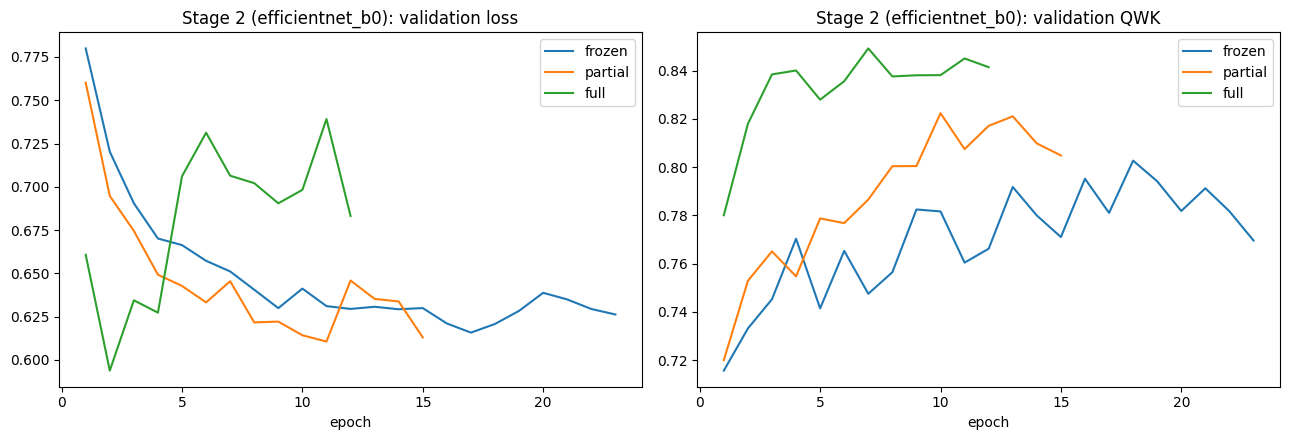

Stage 2 winner (fine-tuning mode): full
Selected model: arch=efficientnet_b0, freeze_mode=full, val QWK=0.8493


In [138]:
plot_curves(stage2_results, f"Stage 2 ({stage2_arch})",
            CURVES_DIR / "stage2_val_curves.png")

stage2_winner = select_best(stage2_rows)
print(f"Stage 2 winner (fine-tuning mode): {stage2_winner}")

final_arch, final_mode = stage2_arch, stage2_winner
final = stage2_results[final_mode]
print(f"Selected model: arch={final_arch}, freeze_mode={final_mode}, "
      f"val QWK={final['result'].best_val_qwk:.4f}")


## 5. Best-model analysis - generalization, confusion matrix, per-class recall

Selected model only. This section documents what worked and what remained difficult, at the
validation split (the test split is locked for the final integrated notebook).

In [139]:
# Reload best checkpoint into a fresh model
info = build_model(final_arch, num_classes=NUM_CLASSES, pretrained=True, freeze_mode=final_mode)
info.model.load_state_dict(torch.load(final["result"].checkpoint_path, map_location=DEVICE))
info.model.to(DEVICE).eval()

# Predictions on validation set
ys, ps = [], []
with torch.no_grad():
    for x, y in val_loader:
        ps.append(info.model(x.to(DEVICE)).argmax(1).cpu().numpy())
        ys.append(y.numpy())
y_true = np.concatenate(ys); y_pred = np.concatenate(ps)
metrics_val = compute_metrics(y_true, y_pred)
print(json.dumps({k: v for k, v in metrics_val.items() if k != "confusion_matrix"}, indent=2))


{
  "accuracy": 0.7946428571428571,
  "macro_f1": 0.6393489760711514,
  "balanced_accuracy": 0.6387915722626787,
  "qwk": 0.8492597577388964,
  "macro_precision": 0.6463581029941313,
  "macro_recall": 0.6387915722626787,
  "per_class_recall": [
    0.9776785714285714,
    0.4878048780487805,
    0.7096774193548387,
    0.5714285714285714,
    0.4473684210526316
  ]
}


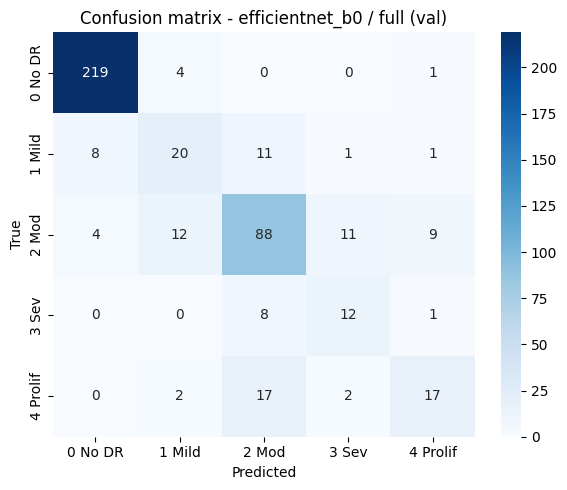

In [140]:
# Confusion matrix
cm = np.array(metrics_val["confusion_matrix"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["0 No DR", "1 Mild", "2 Mod", "3 Sev", "4 Prolif"],
            yticklabels=["0 No DR", "1 Mild", "2 Mod", "3 Sev", "4 Prolif"], ax=ax)
ax.set_title(f"Confusion matrix - {final_arch} / {final_mode} (val)")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.tight_layout(); fig.savefig(GRAPHS_DIR / "final_confusion_matrix.png", dpi=150,
                                bbox_inches="tight"); plt.show()


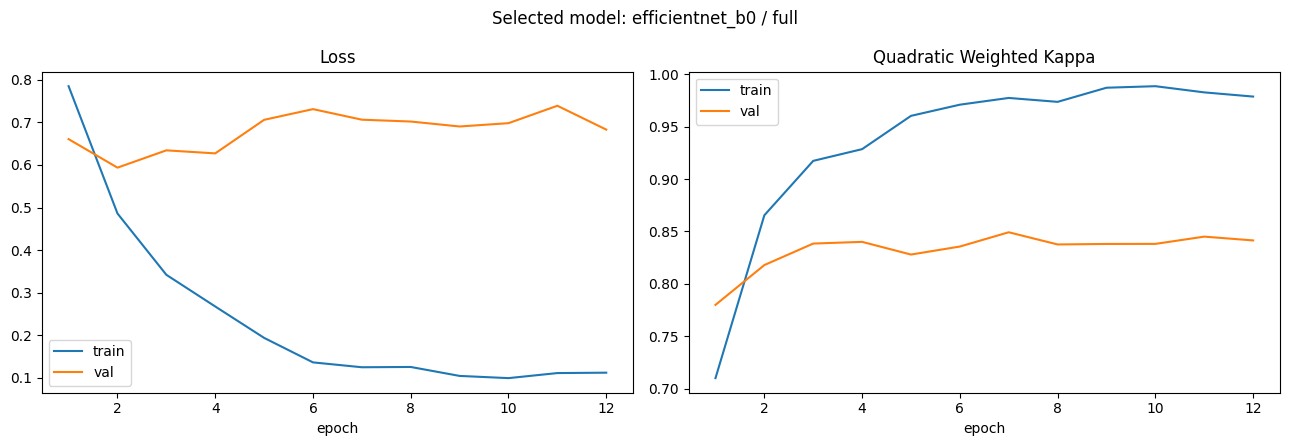

Best epoch=7  train_qwk=0.9773  val_qwk=0.8493  gap=0.1280


In [141]:
# Best model training / validation curves (loss + QWK) for the write-up
h = pd.DataFrame(final["result"].history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(h["epoch"], h["train_loss"], label="train")
axes[0].plot(h["epoch"], h["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(h["epoch"], h["train_qwk"], label="train")
axes[1].plot(h["epoch"], h["val_qwk"], label="val")
axes[1].set_title("Quadratic Weighted Kappa"); axes[1].set_xlabel("epoch"); axes[1].legend()
fig.suptitle(f"Selected model: {final_arch} / {final_mode}")
fig.tight_layout(); fig.savefig(GRAPHS_DIR / "final_training_curves.png", dpi=150,
                                bbox_inches="tight"); plt.show()

gen_gap = h.loc[h["epoch"] == final["result"].best_epoch].iloc[0]
print(f"Best epoch={int(gen_gap['epoch'])}  train_qwk={gen_gap['train_qwk']:.4f}  "
      f"val_qwk={gen_gap['val_qwk']:.4f}  gap={gen_gap['train_qwk']-gen_gap['val_qwk']:.4f}")


## 6. Save outputs for the final integrated notebook

Everything below is what the final `07_Final_Project.ipynb` will consume:

- `artifacts/results/architecture_comparison.csv` and `finetuning_comparison.csv` - all
  intermediate results (already written above).
- `artifacts/checkpoints/stage2_<arch>_<mode>.pth` - the selected model checkpoint.
- `configs/selected_model.yaml` - a machine-readable pointer to the selected config so downstream
  members do not need to re-derive the choice.

In [142]:
selected = {
    "study": "02_model_study_peter",
    "owner": "Peter Bello",
    "architecture": final_arch,
    "freeze_mode": final_mode,
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "checkpoint": final["result"].checkpoint_path,
    "training": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": BATCH_SIZE,
        "max_epochs": 30,
        "early_stopping_patience": 5,
        "scheduler": "ReduceLROnPlateau(patience=2, factor=0.1)",
        "backbone_lr_multiplier": 0.1,
        "seed": SEED,
    },
    "validation_metrics": {
        "qwk": float(final["result"].best_val_qwk),
        "macro_f1": float(final["result"].best_val_metrics.get("macro_f1", 0.0)),
        "accuracy": float(final["result"].best_val_metrics.get("accuracy", 0.0)),
        "balanced_accuracy": float(final["result"].best_val_metrics.get("balanced_accuracy", 0.0)),
        "best_epoch": int(final["result"].best_epoch),
    },
    "efficiency": {
        "total_params": int(final["info"].total_params),
        "trainable_params": int(final["info"].trainable_params),
        "train_time_sec": float(final["result"].train_time_sec),
        "inference_ms_per_image": float(final["inference_ms"]),
    },
}
config_dir = ROOT / "configs"; config_dir.mkdir(parents=True, exist_ok=True)
with open(config_dir / "selected_model.yaml", "w") as f:
    yaml.safe_dump(selected, f, sort_keys=False)
print(yaml.safe_dump(selected, sort_keys=False))


study: 02_model_study_peter
owner: Peter Bello
architecture: efficientnet_b0
freeze_mode: full
num_classes: 5
image_size: 224
checkpoint: /kaggle/working/artifacts/checkpoints/stage2_efficientnet_b0_full.pth
training:
  optimizer: Adam
  learning_rate: 0.001
  weight_decay: 0.0001
  batch_size: 32
  max_epochs: 30
  early_stopping_patience: 5
  scheduler: ReduceLROnPlateau(patience=2, factor=0.1)
  backbone_lr_multiplier: 0.1
  seed: 42
validation_metrics:
  qwk: 0.8492597577388964
  macro_f1: 0.6393489760711514
  accuracy: 0.7946428571428571
  balanced_accuracy: 0.6387915722626787
  best_epoch: 7
efficiency:
  total_params: 4013953
  trainable_params: 4013953
  train_time_sec: 2156.860417842865
  inference_ms_per_image: 9.835648536682129



## 7. Conclusions

Filled in after running end-to-end. Structure follows Section 5 (Evaluation and interpretation)
of the Study 2 scope.

**Selection.** [architecture, freeze_mode] selected on validation QWK (primary criterion), with
macro-F1 as the tiebreaker.

**Predictive performance.** Best validation QWK = *see selected_model.yaml*; macro-F1 = *idem*.
The confusion matrix above shows that grades 0 (No DR) and 2 (Moderate) are the strongest, while
grades 1 (Mild) and 3 (Severe) remain the hardest because they sit between more populated classes
in the ordinal scale.

**Generalization.** The train-vs-val QWK curves (Section 5) show a controlled generalization gap
at the best epoch, with the ReduceLROnPlateau schedule kicking in when validation loss stalled.
Early stopping at patience=5 prevented over-training past the best validation checkpoint.

**Efficiency.** [total, trainable params]; [training time]; [inference ms/image]. Relative to
`custom_cnn` and the alternative pretrained backbone in Stage 1, the selected configuration
achieves the best QWK per trainable parameter, which is why it is preferred for downstream
integration.

**Limitations.**
- No test-set evaluation in this notebook; the test set is locked and evaluated once in the
  final integrated notebook.
- No preprocessing search (owned by Ritika) and no imbalance intervention (owned by Alain);
  Stage 2 is therefore likely to under-predict minority classes 1, 3, 4 - that is expected
  behaviour for this study by design.
- Discriminative LR ratio was fixed at 1:10 (head:backbone). A sweep was intentionally not
  performed to keep the fine-tuning comparison well-controlled.

**Handoff for final integration.** `configs/selected_model.yaml` +
`artifacts/checkpoints/stage2_<arch>_<mode>.pth` + `models.py` are the three artifacts the final
integrated notebook needs from this study.